In [22]:
import sys
print(sys.executable)

/usr/local/anaconda3.2024/bin/python


In [23]:
from transformers import BertTokenizerFast, BertModel
from transformers import RobertaTokenizerFast, RobertaModel
import spacy
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
import os

In [24]:
from data import *
from model import *
from utilsv2 import *

In [25]:
os.environ["TOKENIZERS_PARALLELISM"] = "true"

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Khởi tạo tokenizer và model BERT
tokenizer_bert = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")

# tokenizer_bert = RobertaTokenizerFast.from_pretrained("roberta-base")
# bert = RobertaModel.from_pretrained("roberta-base")


# Thêm token đặc biệt nếu chưa có
special_tokens = {"additional_special_tokens": ["[E1]", "[/E1]", "[E2]", "[/E2]"]}
num_added_toks = tokenizer_bert.add_special_tokens(special_tokens)
bert.resize_token_embeddings(len(tokenizer_bert))  # Resize embedding BERT


# Tokenizer và DataLoader
spacy_nlp = spacy.load('en_core_web_sm')
spacy_nlp.tokenizer = create_custom_tokenizer(spacy_nlp, special_tokens['additional_special_tokens'])

In [27]:
data_source = "/data/ddao/TRE/data/raw_data/TDDiscourse/TDDManProcessed/"
data_train_path = data_source + "train.csv"
data_valid_path = data_source + "dev.csv"
data_test_path = data_source + "test.csv"

train_df = pd.read_csv(data_train_path)
valid_df = pd.read_csv(data_valid_path)
test_df = pd.read_csv(data_test_path)

# Mã hóa nhãn
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
valid_df['label_encoded'] = label_encoder.transform(valid_df['label'])
test_df['label_encoded'] = label_encoder.transform(test_df['label'])


label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label Mapping: {label_mapping}")
relations = list(label_mapping.keys())

print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)
print("test_df:", test_df.shape)


Label Mapping: {'a': 0, 'b': 1, 'i': 2, 'ii': 3, 's': 4}
train_df: (4000, 12)
valid_df: (650, 12)
test_df: (1500, 12)


In [28]:
# --- Thống kê số lượng quan hệ trong từng tập ---
def count_relations(df, name="Dataset"):
    counts = df['label'].value_counts().sort_index()
    percents = (counts / len(df) * 100).round(2)
    stats_df = pd.DataFrame({
        'Relation': counts.index,
        f'{name} Count': counts.values,
        f'{name} %': percents.values
    })
    return stats_df

# Gộp kết quả ba tập thành một bảng duy nhất
train_stats = count_relations(train_df, "Train")
valid_stats = count_relations(valid_df, "Valid")
test_stats  = count_relations(test_df, "Test")

# Gộp tất cả vào một bảng chung (theo cột Relation)
summary_df = train_stats.merge(valid_stats, on="Relation", how="outer") \
                        .merge(test_stats, on="Relation", how="outer") \
                        .fillna(0)

# Thêm tổng cộng cho từng loại quan hệ
summary_df["Total Count"] = summary_df["Train Count"] + summary_df["Valid Count"] + summary_df["Test Count"]
summary_df["Total %"] = (summary_df["Total Count"] / summary_df["Total Count"].sum() * 100).round(2)

print("\n📊 Relation Statistics (MATRES):\n")
print(summary_df.to_string(index=False))


📊 Relation Statistics (MATRES):

Relation  Train Count  Train %  Valid Count  Valid %  Test Count  Test %  Total Count  Total %
       a          613    15.32          253    38.92         188   12.53         1054    17.14
       b          988    24.70          172    26.46         401   26.73         1561    25.38
       i         1312    32.80          124    19.08         572   38.13         2008    32.65
      ii         1022    25.55           72    11.08         293   19.53         1387    22.55
       s           65     1.62           29     4.46          46    3.07          140     2.28


In [29]:
print("Create dataloader:")
batch_size = 128
window_size = 128
MAX_LENGTH = 256
shuffle=False
print("batch_size: ", batch_size)
print("window_size: ", window_size)
print("MAX_LENGTH: ", MAX_LENGTH)

Create dataloader:
batch_size:  128
window_size:  128
MAX_LENGTH:  256


In [11]:
# train_dataloader = create_dataloader(train_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TDD=True)
# validation_dataloader = create_dataloader(valid_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TDD=True)
# test_dataloader = create_dataloader(test_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TDD=True)

In [30]:
train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/train_dataloader_ws_{window_size}.pt"
validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/validation_dataloader_ws_{window_size}.pt"
test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/test_dataloader_ws_{window_size}.pt"


# train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/train_dataloader_ws_{window_size}_RoBERTa.pt"
# validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/validation_dataloader_ws_{window_size}_RoBERTa.pt"
# test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/test_dataloader_ws_{window_size}_RoBERTa.pt"

In [31]:
# torch.save(train_dataloader, train_dataloader_path)
# torch.save(validation_dataloader, validation_dataloader_path)
# torch.save(test_dataloader, test_dataloader_path)

In [32]:
train_dataloader = torch.load(train_dataloader_path)
validation_dataloader = torch.load(validation_dataloader_path)
test_dataloader = torch.load(test_dataloader_path)

In [33]:
# ============================================================
# Hyperparameters
# ============================================================
hidden_ffn_dim   = 512
num_heads        = 8
num_layers       = 1
dropout          = 0.3
num_classes      = len(label_encoder.classes_)

num_epochs       = 30
eval_step        = 1
LEARNING_RATE    = 1e-5

top_k            = 10

print(f"hidden_ffn_dim: {hidden_ffn_dim}")
print(f"num_layers: {num_layers}")
print(f"num_heads: {num_heads}")
print(f"top_k: {top_k}")

# ============================================================
# Save path
# ============================================================

# save_path = (
#     f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/"
#     f"FTBERT_TDDManu_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}_backup.pth"
# )

save_path = (
    f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/"
    f"FTRoBERTa_TDDManu_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}.pth"
)

print('Model will save at:', save_path)

hidden_ffn_dim: 512
num_layers: 1
num_heads: 8
top_k: 10
Model will save at: /data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/FTRoBERTa_TDDManu_MHA_1_FFN_512_TOP_10.pth


In [34]:
print("\nCreate model:")
model = TemporalRelationModelV2(
    bert=bert,
    tokenizer=tokenizer_bert,
    hidden_ffn_dim=hidden_ffn_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
    num_classes=num_classes,
    device=device
).to(device)

print("Device:", device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("--" * 20)


Create model:
Device: cuda
----------------------------------------


/home/prof/ddao/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [35]:
print("\nStart Training...")
losses = train_model(
    model=model,
    top_k=top_k,
    train_dataloader=train_dataloader,
    validation_dataloader=validation_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=num_epochs,
    save_path=save_path,
    eval_step=eval_step,
    max_grad_norm=1.0,      # clip grad
    lambda_aux=1.0,         # weight cho aux loss (0 nếu không dùng)
    is_TDD=True
)


Start Training...


Training epoch 1:: 100%|██████████| 32/32 [00:55<00:00,  1.74s/it]


Epoch 1: Loss=6.6788, Skipped 0/4000 (0.00% VAGUE) | Time=55.79s


Evaluating: 100%|██████████| 6/6 [00:02<00:00,  2.08it/s]


Evaluation finished in 2.89s.
[TDD] F1=0.2938, P=0.2938, R=0.2938
→ Eval epoch 1: F1=0.2938, P=0.2938, R=0.2938


...

Evaluation finished in 2.91s.
[TDD] F1=0.4246, P=0.4246, R=0.4246
→ Eval epoch 29: F1=0.4246, P=0.4246, R=0.4246


Training epoch 30:: 100%|██████████| 32/32 [00:56<00:00,  1.77s/it]


Epoch 30: Loss=0.1767, Skipped 0/4000 (0.00% VAGUE) | Time=56.55s


Evaluating: 100%|██████████| 6/6 [00:02<00:00,  2.06it/s]

Evaluation finished in 2.92s.
[TDD] F1=0.4692, P=0.4692, R=0.4692
→ Eval epoch 30: F1=0.4692, P=0.4692, R=0.4692
Training finished in 2169.91s.


# Evaluate

In [36]:
print("Load pretrained model:")
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Model saved at epoch {epoch}, loss = {loss:.4f}")

Load pretrained model:
Model saved at epoch 29, loss = 0.1767


In [38]:
metrics_by_topk = grid_search(test_dataloader,
                                model,
                                20,
                                device,
                                is_TDD=True)

Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.85it/s]


Evaluation finished in 6.50s.
[TDD] F1=0.4780, P=0.4780, R=0.4780
top_K: 0 - F1: 0.4780 | Precision: 0.4780 | Recall: 0.4780



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.87it/s]


Evaluation finished in 6.43s.
[TDD] F1=0.4880, P=0.4880, R=0.4880
top_K: 1 - F1: 0.4880 | Precision: 0.4880 | Recall: 0.4880



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.85it/s]


...

Evaluation finished in 6.77s.
[TDD] F1=0.4940, P=0.4940, R=0.4940
top_K: 18 - F1: 0.4940 | Precision: 0.4940 | Recall: 0.4940



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.77it/s]


Evaluation finished in 6.77s.
[TDD] F1=0.4913, P=0.4913, R=0.4913
top_K: 19 - F1: 0.4913 | Precision: 0.4913 | Recall: 0.4913



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.78it/s]

Evaluation finished in 6.76s.
[TDD] F1=0.4913, P=0.4913, R=0.4913
top_K: 20 - F1: 0.4913 | Precision: 0.4913 | Recall: 0.4913



In [39]:
# Tạo DataFrame
df = pd.DataFrame(metrics_by_topk, columns=["top_k", "F1", "Precision", "Recall"])
df.to_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/metrics_by_topk.csv", index=False, encoding='utf-8-sig')

In [40]:
df = pd.read_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/metrics_by_topk.csv", encoding='utf-8-sig')

In [41]:
# Lấy hàng có F1 cao nhất
best_row = df.loc[df['F1'].idxmax()]

best_k = int(best_row['top_k'])
best_f1 = best_row['F1']
best_p = best_row['Precision']
best_r = best_row['Recall']

print(f"✅ Top-K tốt nhất: {best_k}")
print(f"F1 = {best_f1:.4f} | Precision = {best_p:.4f} | Recall = {best_r:.4f}")


✅ Top-K tốt nhất: 2
F1 = 0.4973 | Precision = 0.4973 | Recall = 0.4973


In [42]:
cm, f1, p, r, precisions, recalls, f1s, all_predictions, all_labels, logs = evaluate(test_dataloader,
                                                    model=model,
                                                    top_k=best_k,
                                                    device=device,
                                                    return_preds=True,
                                                    is_TDD=True,
                                                    return_topk_tokens=True,
                                                    return_logs=True
                                                    )

Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.76it/s]

Evaluation finished in 6.81s.
[TDD] F1=0.4973, P=0.4973, R=0.4973


In [27]:
torch.cuda.empty_cache()

# Top-k Analysis

In [44]:
from analysis_topk import *

In [45]:
id2label = {v:k for k, v in label_mapping.items()}

In [46]:
# df_expanded = add_is_intra_batch(train_df, batch_size=64)
df_expanded = add_is_intra_batch(test_df, spacy_nlp, batch_size=64)

In [47]:
d4A = build_analysis_dataset(all_labels,
                             all_predictions,
                             logs,
                             id2label,
                             entity_pairs=df_expanded.values.tolist(),
                             vocab=spacy_nlp.vocab)  # giúp decode id → string)

In [50]:
# Write dictionary to JSON file
with open("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/test_data4analyze.json", "w") as json_file:
    json.dump(d4A, json_file, indent=4)

In [51]:
df_analysis = create_analysis_dataframe(d4A)

In [52]:
# df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/train_D4A.json")
df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/test_D4A.json")


In [53]:
# df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/train_D4A.json")
df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TDDManu/test_D4A.json")

POS distribution per entity_type:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.077333  0.100667  0.017000  0.097000  0.031333  0.112333   
e2           0.077667  0.108333  0.031667  0.052000  0.031667  0.073333   
pair         0.079333  0.108333  0.026000  0.048667  0.040333  0.110000   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.195000  0.019333  0.047667  0.050333  0.127333  0.013667   
e2           0.215333  0.049000  0.026333  0.040333  0.117000  0.018000   
pair         0.194333  0.043333  0.024000  0.056000  0.139667  0.012667   

pos             SCONJ       SYM   VERB         X  
entity_type                                       
e1           0.015333  0.001333  0.092  0.002333  
e2           0.022333  0.006333  0.129  0.001667  
pair      

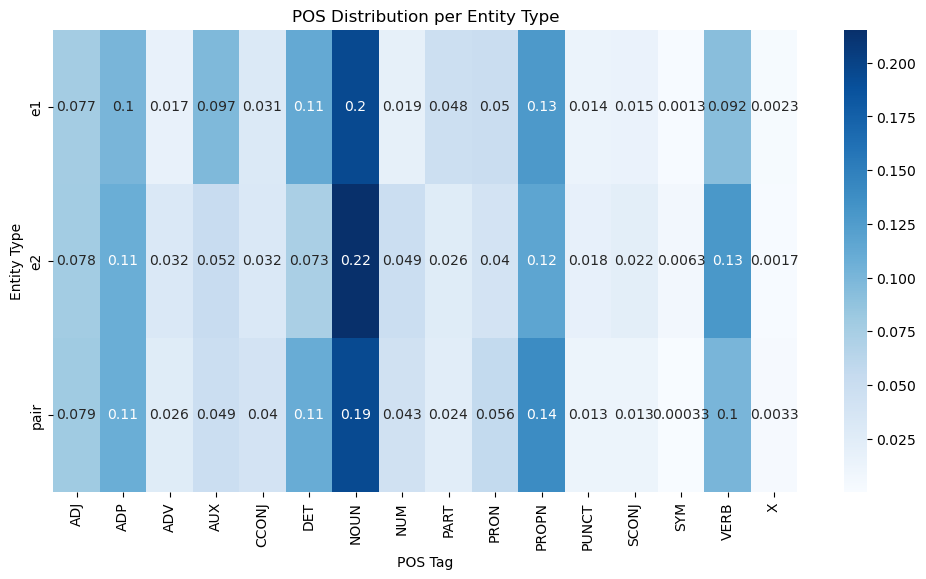

In [54]:
pos_distribution(df_analysis)

Dependency distribution per entity_type:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.017000  0.009333  0.004000  0.018000  0.020667  0.000000   
e2           0.014667  0.012000  0.003333  0.025000  0.033000  0.001333   
pair         0.014667  0.010000  0.014667  0.018667  0.033000  0.008000   

dep              amod     appos      attr       aux  ...     pcomp      pobj  \
entity_type                                          ...                       
e1           0.076000  0.007667  0.003000  0.081000  ...  0.009000  0.084667   
e2           0.075000  0.005333  0.003000  0.045333  ...  0.003667  0.090333   
pair         0.064333  0.005667  0.005333  0.042000  ...  0.002000  0.119667   

dep              poss   preconj      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.018000  0.000333 

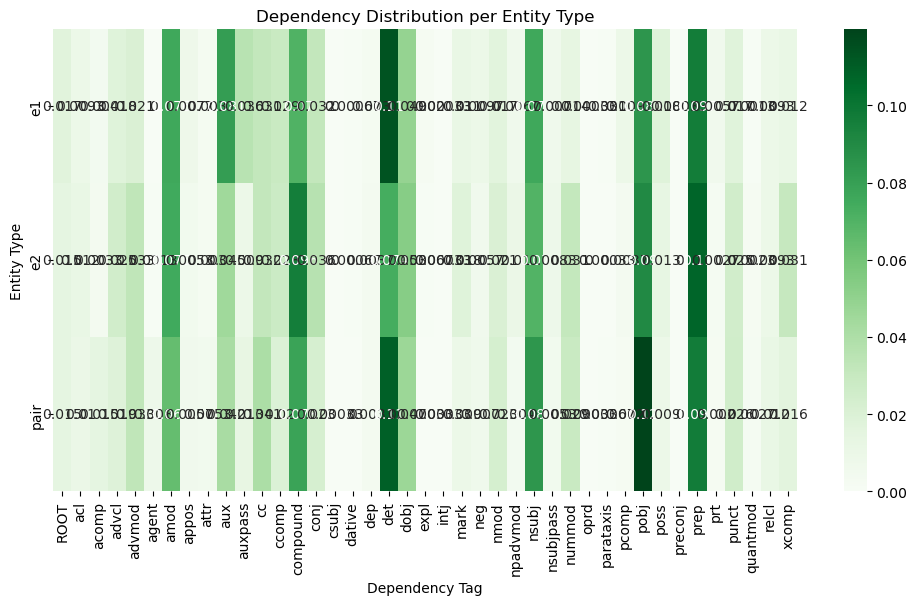

In [55]:
dep_distribution(df_analysis)

Morphology distribution per entity_type:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.191667                              0.020667   
e2           0.194000                              0.031333   
pair         0.174333                              0.027000   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.020000   
e2                                       0.016667   
pair                                     0.015333   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.001667        
pair                                                  0.000667        

morph        Case=Acc

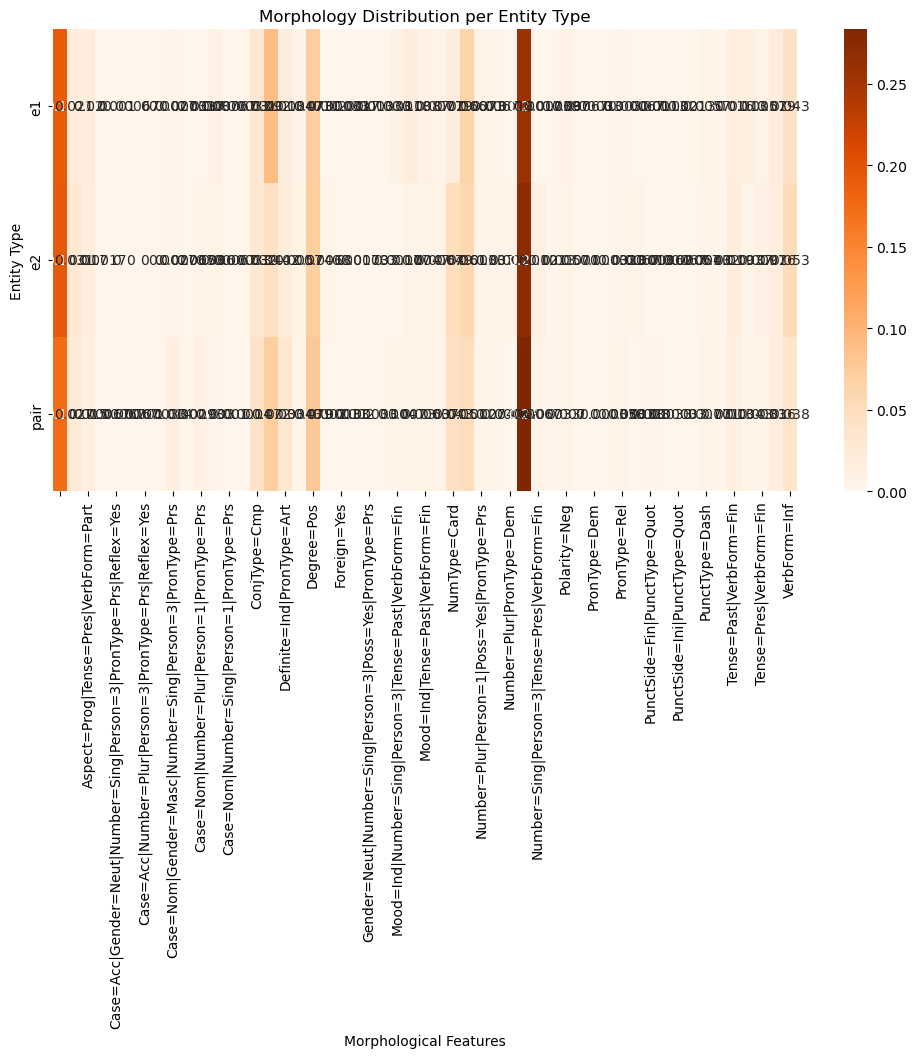

In [56]:
morph_distribution(df_analysis)

Số cặp với prediction đúng: 4476

=== Relation: i ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.084975  0.081281  0.011084  0.125616  0.025862  0.139163   
e2           0.081281  0.092365  0.029557  0.060345  0.027094  0.066502   
pair         0.084975  0.098522  0.020936  0.038177  0.048030  0.119458   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.163793  0.009852  0.056650  0.061576  0.114532  0.016010   
e2           0.221675  0.034483  0.017241  0.048030  0.134236  0.014778   
pair         0.185961  0.034483  0.017241  0.055419  0.185961  0.016010   

pos             SCONJ       SYM      VERB         X  
entity_type                                          
e1           0.020936  0.000000  0.088670  0.000000  
e2           0

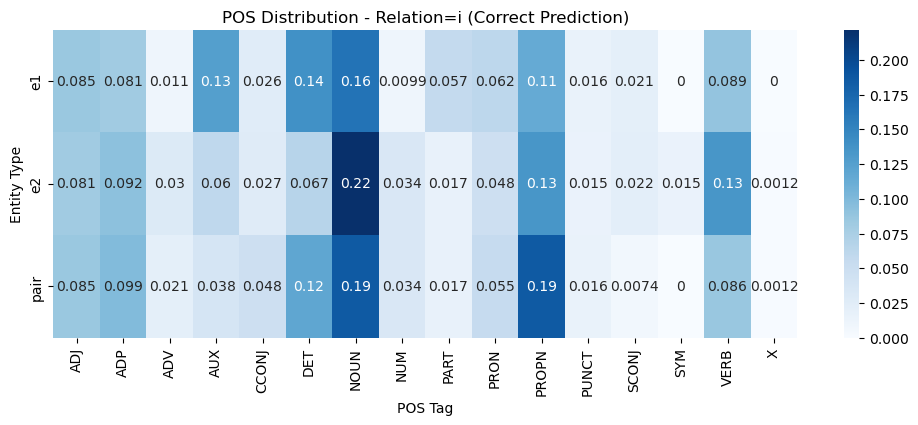

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.009852  0.013547  0.001232  0.017241  0.011084  0.000000   
e2           0.008621  0.002463  0.001232  0.018473  0.027094  0.000000   
pair         0.018473  0.006158  0.034483  0.008621  0.023399  0.004926   

dep              amod     appos      attr       aux  ...     pcomp      pobj  \
entity_type                                          ...                       
e1           0.087438  0.012315  0.003695  0.102217  ...  0.011084  0.084975   
e2           0.076355  0.008621  0.001232  0.048030  ...  0.001232  0.092365   
pair         0.061576  0.000000  0.012315  0.040640  ...  0.002463  0.139163   

dep              poss   preconj      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.030788  0.001232  0.078818  0.001

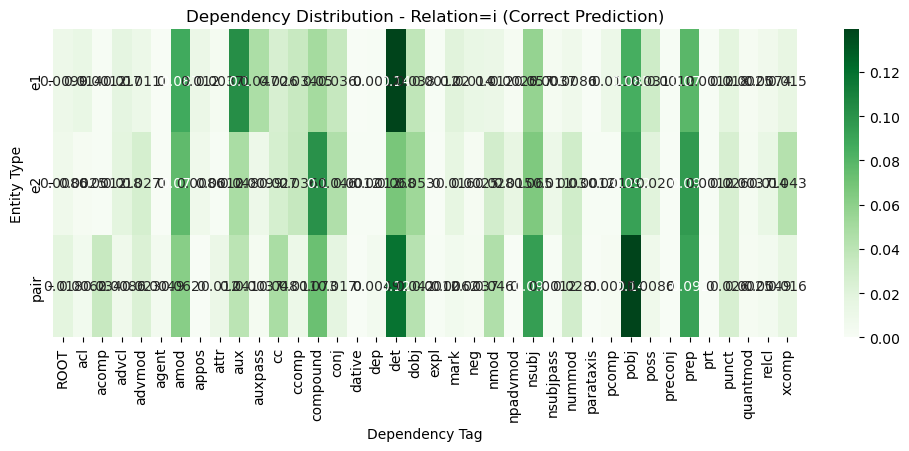

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.178571                              0.024631   
e2           0.179803                              0.035714   
pair         0.145320                              0.024631   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.022167   
e2                                       0.025862   
pair                                     0.006158   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.001232        
pair                                                  0.000000        

morph        Case=Acc|Gender=Neut|Num

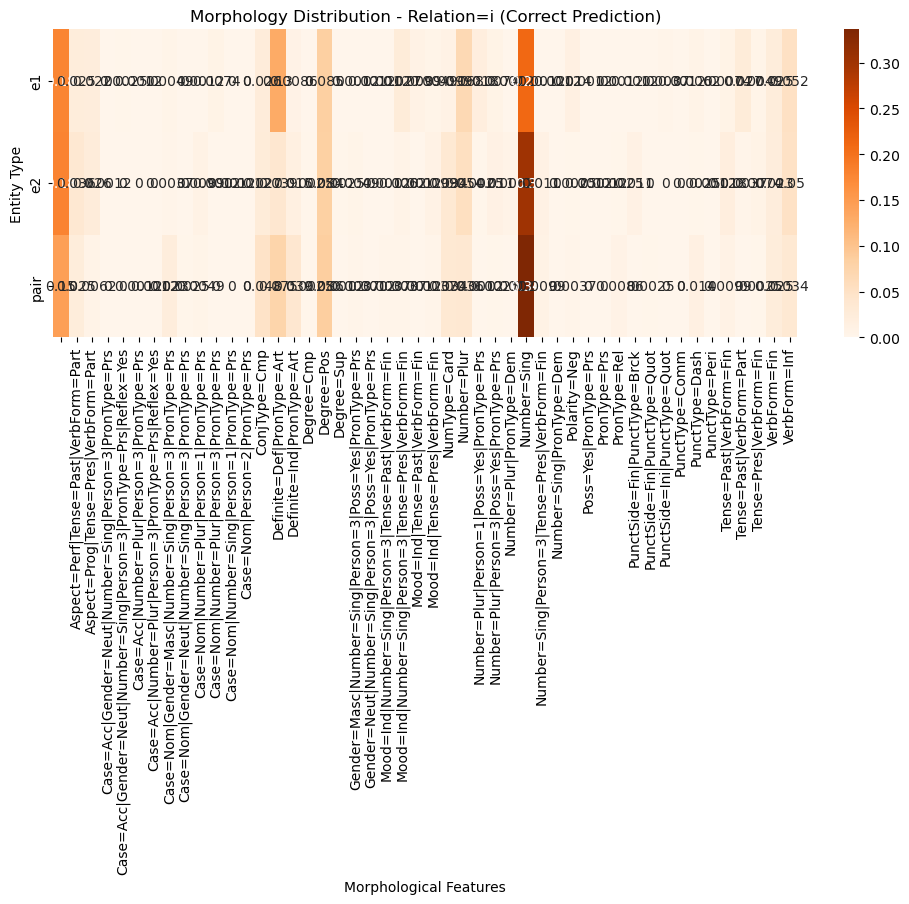


=== Relation: ii ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.097015  0.115672  0.022388  0.078358  0.018657  0.089552   
e2           0.082090  0.119403  0.048507  0.070896  0.022388  0.052239   
pair         0.044776  0.134328  0.041045  0.067164  0.033582  0.097015   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.212687  0.026119  0.033582  0.063433  0.130597  0.007463   
e2           0.186567  0.052239  0.037313  0.026119  0.097015  0.041045   
pair         0.201493  0.014925  0.041045  0.074627  0.115672  0.007463   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.007463  0.097015  0.000000  
e2           0.007463  0.156716  0.000000  
pair         0.018657  0.100746 

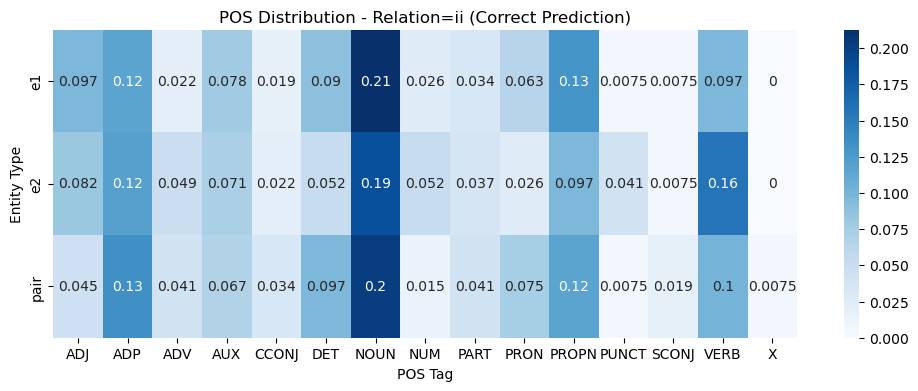

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.022388  0.003731  0.003731  0.018657  0.026119  0.000000   
e2           0.029851  0.022388  0.003731  0.037313  0.052239  0.000000   
pair         0.007463  0.029851  0.003731  0.018657  0.048507  0.003731   

dep              amod     appos      attr       aux  ...    nummod     pcomp  \
entity_type                                          ...                       
e1           0.093284  0.007463  0.000000  0.055970  ...  0.011194  0.007463   
e2           0.100746  0.000000  0.003731  0.067164  ...  0.029851  0.022388   
pair         0.033582  0.000000  0.007463  0.041045  ...  0.007463  0.000000   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.115672  0.026119  0.108209  0.014

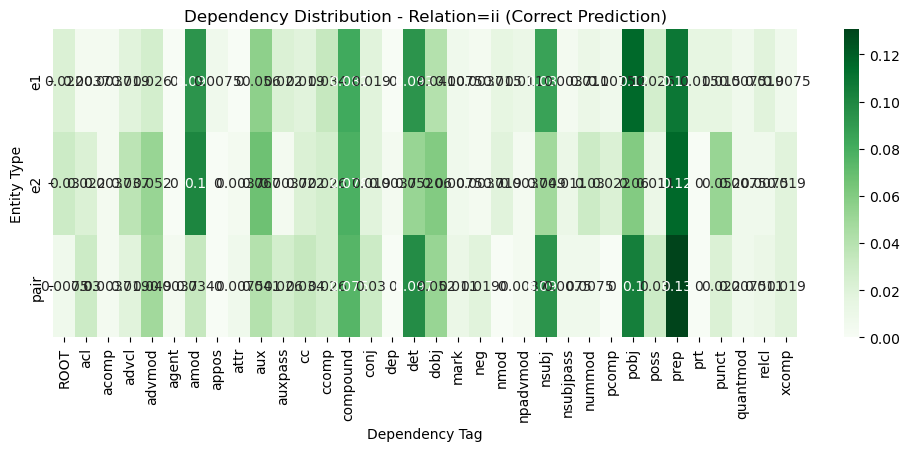

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.182836                              0.014925   
e2           0.194030                              0.041045   
pair         0.231343                              0.037313   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.029851   
e2                                       0.014925   
pair                                     0.033582   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.003731        
pair                                                  0.000000        

morph        Case=Acc|Gender=Neut|Num

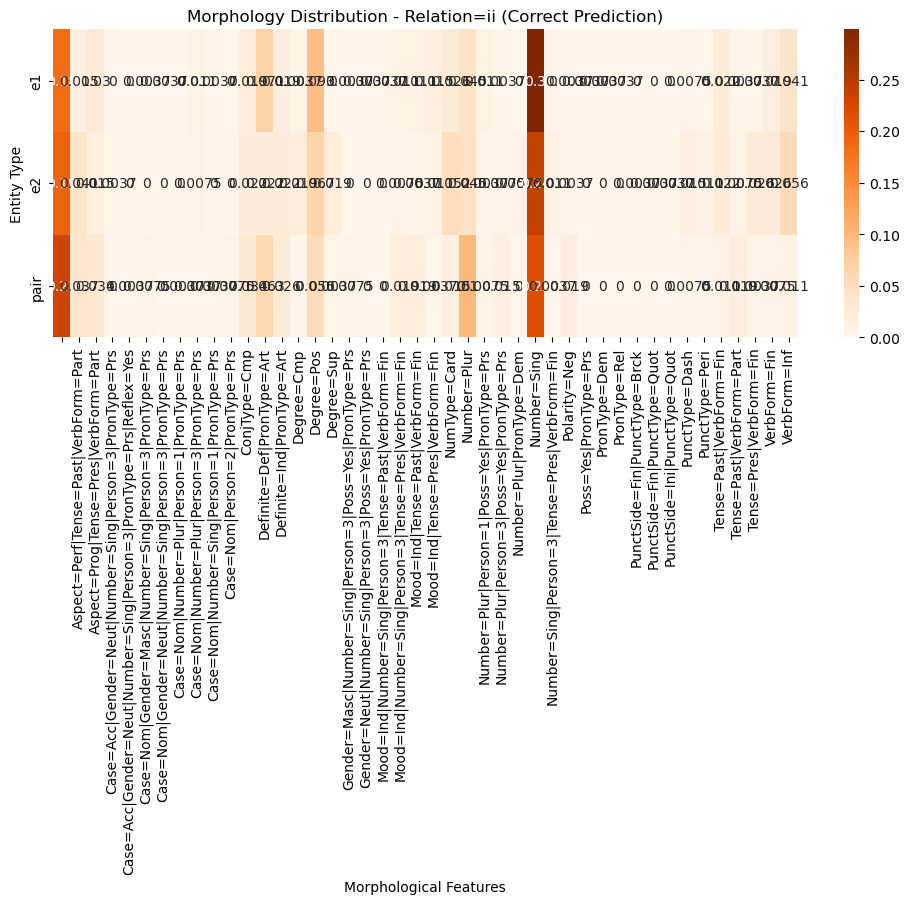


=== Relation: s ===
POS distribution:
pos            ADJ    ADP    AUX    DET  NOUN    NUM   PART  PROPN   VERB  \
entity_type                                                                 
e1           0.000  0.000  0.000  0.250  0.00  0.000  0.000   0.25  0.375   
e2           0.125  0.125  0.125  0.000  0.25  0.125  0.125   0.00  0.125   
pair         0.000  0.375  0.000  0.125  0.50  0.000  0.000   0.00  0.000   

pos              X  
entity_type         
e1           0.125  
e2           0.000  
pair         0.000  


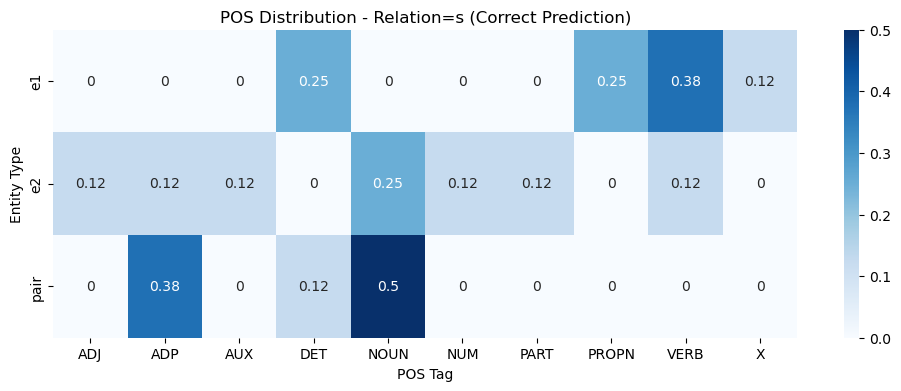

Dependency distribution:
dep           ROOT   aux  compound   conj    dep    det   dobj  npadvmod  \
entity_type                                                                
e1           0.125  0.00     0.000  0.125  0.125  0.250  0.125     0.125   
e2           0.000  0.25     0.125  0.125  0.000  0.000  0.000     0.000   
pair         0.000  0.00     0.125  0.000  0.000  0.125  0.375     0.000   

dep          nummod   pobj   prep  relcl  xcomp  
entity_type                                      
e1            0.000  0.000  0.000  0.000  0.125  
e2            0.125  0.125  0.125  0.125  0.000  
pair          0.000  0.000  0.375  0.000  0.000  


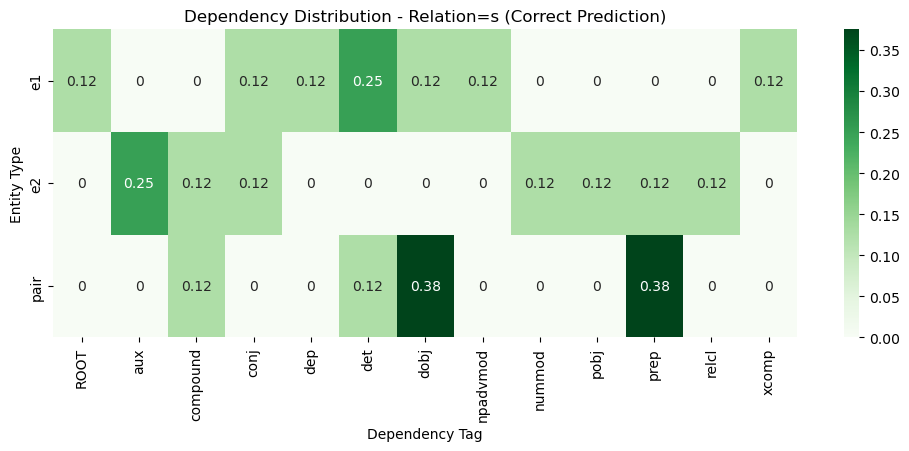

Morphology distribution:
morph               Definite=Def|PronType=Art  Degree=Pos  NumType=Card  \
entity_type                                                               
e1           0.125                      0.250       0.000         0.000   
e2           0.250                      0.000       0.125         0.125   
pair         0.375                      0.125       0.000         0.000   

morph        Number=Plur  Number=Sing  Tense=Past|VerbForm=Fin  \
entity_type                                                      
e1                 0.125        0.125                    0.125   
e2                 0.125        0.125                    0.125   
pair               0.000        0.500                    0.000   

morph        Tense=Pres|VerbForm=Fin  VerbForm=Fin  VerbForm=Inf  
entity_type                                                       
e1                             0.125         0.000         0.125  
e2                             0.000         0.125         0.000  


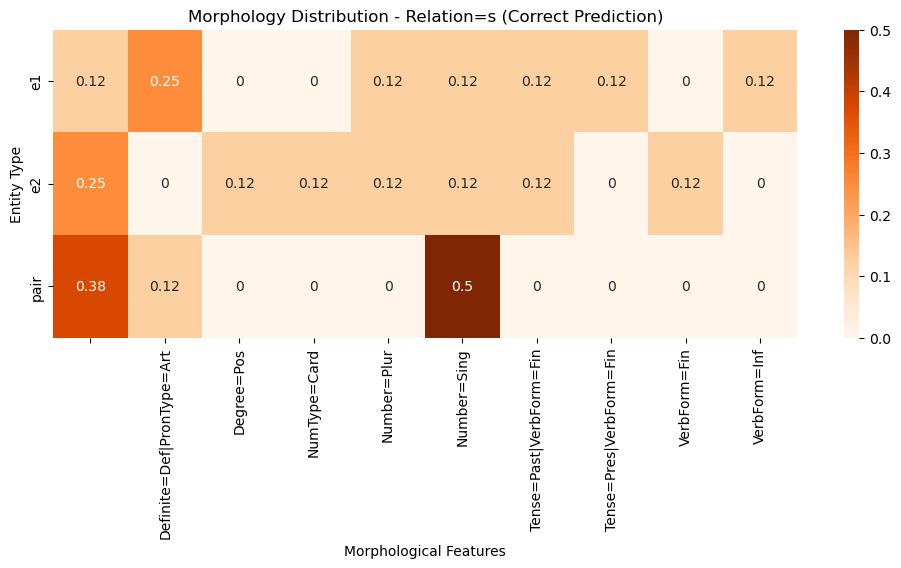


=== Relation: b ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.079268  0.088415  0.030488  0.045732  0.027439  0.131098   
e2           0.057927  0.112805  0.033537  0.057927  0.030488  0.100610   
pair         0.079268  0.118902  0.030488  0.048780  0.030488  0.097561   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.204268  0.024390  0.039634  0.030488  0.149390  0.024390   
e2           0.179878  0.060976  0.030488  0.036585  0.146341  0.015244   
pair         0.219512  0.045732  0.027439  0.054878  0.106707  0.015244   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.015244  0.103659  0.006098  
e2           0.027439  0.100610  0.009146  
pair         0.003049  0.118902  

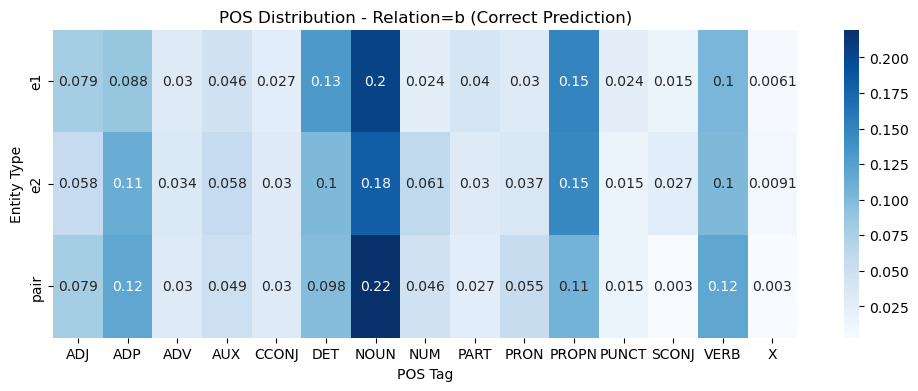

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.021341  0.009146  0.003049  0.009146  0.033537  0.000000   
e2           0.015244  0.012195  0.009146  0.015244  0.033537  0.006098   
pair         0.015244  0.012195  0.006098  0.027439  0.039634  0.036585   

dep              amod     appos      attr       aux  ...    nummod  parataxis  \
entity_type                                          ...                        
e1           0.076220  0.000000  0.000000  0.051829  ...  0.024390   0.000000   
e2           0.039634  0.003049  0.003049  0.042683  ...  0.027439   0.000000   
pair         0.060976  0.003049  0.003049  0.039634  ...  0.024390   0.003049   

dep             pcomp      pobj      poss      prep       prt     punct  \
entity_type                                                               
e1           0.000000  0.088415  0.012195  

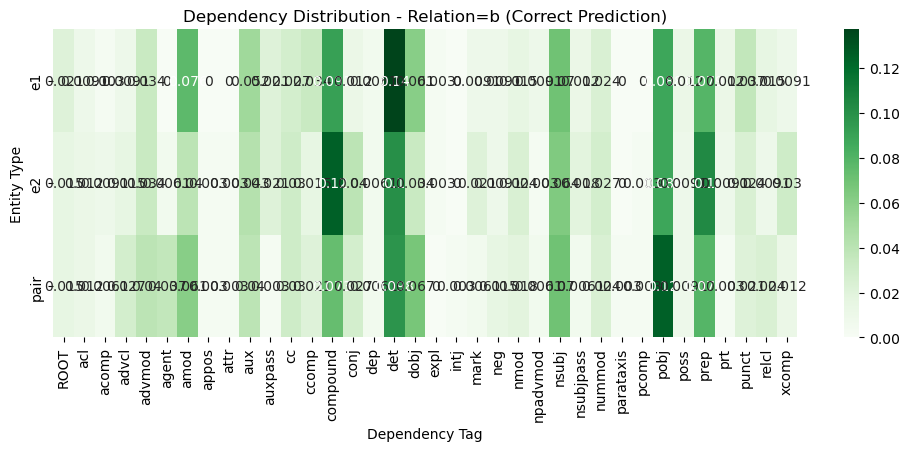

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.182927                              0.030488   
e2           0.216463                              0.027439   
pair         0.167683                              0.042683   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.012195   
e2                                       0.006098   
pair                                     0.015244   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.003049        
pair                                                  0.003049        

morph        Case=Nom|Gender=Masc|Num

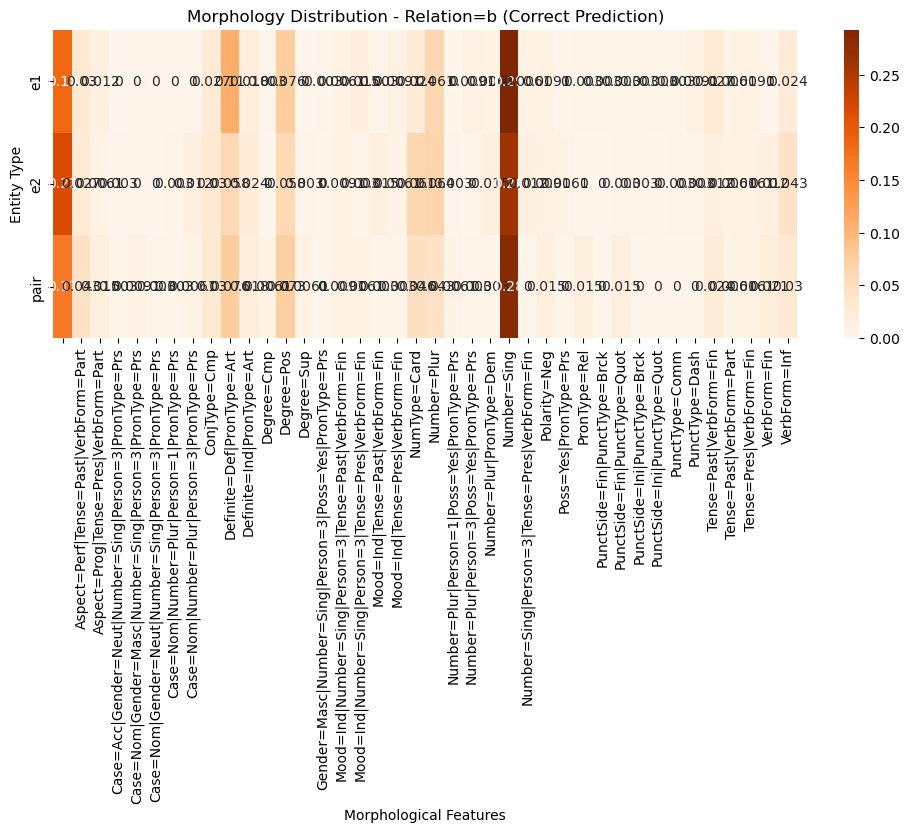


=== Relation: a ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.026316  0.144737  0.000000  0.144737  0.013158  0.078947   
e2           0.052632  0.131579  0.039474  0.013158  0.065789  0.078947   
pair         0.197368  0.078947  0.039474  0.078947  0.052632  0.065789   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.144737  0.039474  0.052632  0.039474  0.171053  0.013158   
e2           0.263158  0.105263  0.026316  0.026316  0.118421  0.000000   
pair         0.171053  0.078947  0.000000  0.026316  0.039474  0.000000   

pos             SCONJ      VERB  
entity_type                      
e1           0.026316  0.105263  
e2           0.000000  0.078947  
pair         0.039474  0.131579  


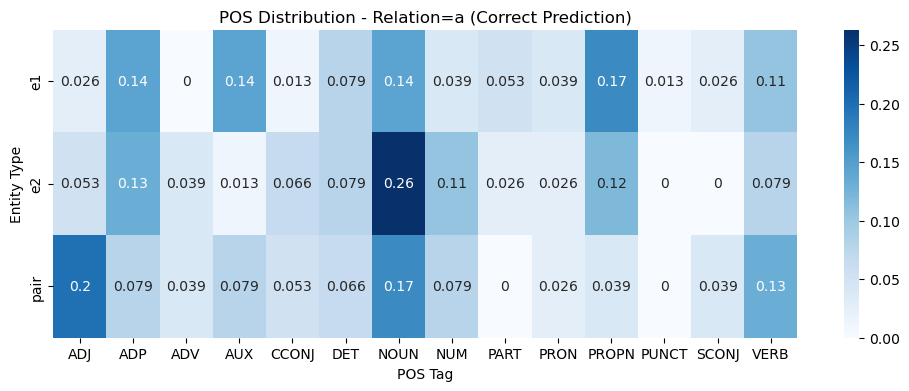

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.026316  0.026316  0.000000  0.105263  0.026316  0.000000   
e2           0.039474  0.000000  0.000000  0.000000  0.039474  0.000000   
pair         0.052632  0.026316  0.013158  0.039474  0.052632  0.013158   

dep              amod     appos       aux   auxpass  ...  nsubjpass    nummod  \
entity_type                                          ...                        
e1           0.026316  0.013158  0.092105  0.052632  ...   0.000000  0.026316   
e2           0.052632  0.000000  0.026316  0.000000  ...   0.013158  0.052632   
pair         0.197368  0.013158  0.052632  0.013158  ...   0.013158  0.013158   

dep             pcomp      pobj      poss      prep       prt     punct  \
entity_type                                                               
e1           0.013158  0.078947  0.013158  

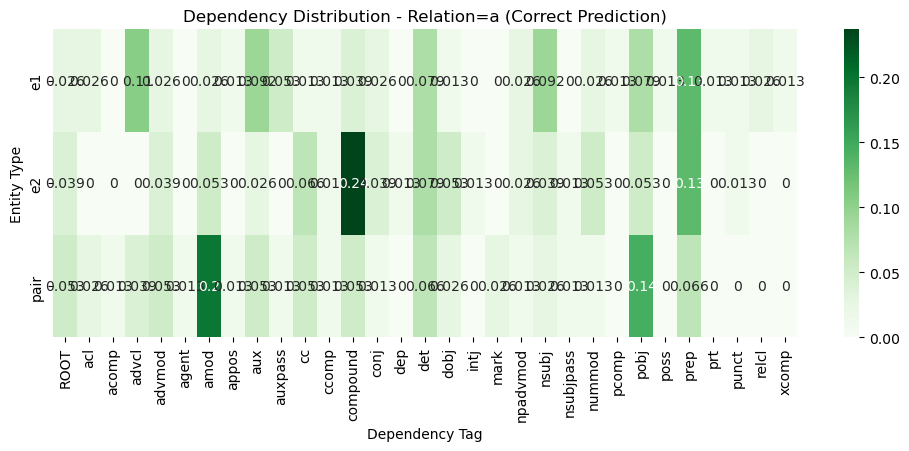

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.263158                              0.039474   
e2           0.197368                              0.039474   
pair         0.184211                              0.039474   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.026316   
e2                                       0.026316   
pair                                     0.013158   

morph        Case=Nom|Gender=Masc|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.000000        
pair                                                  0.013158        

morph        Case=Nom|Number=Plur|Per

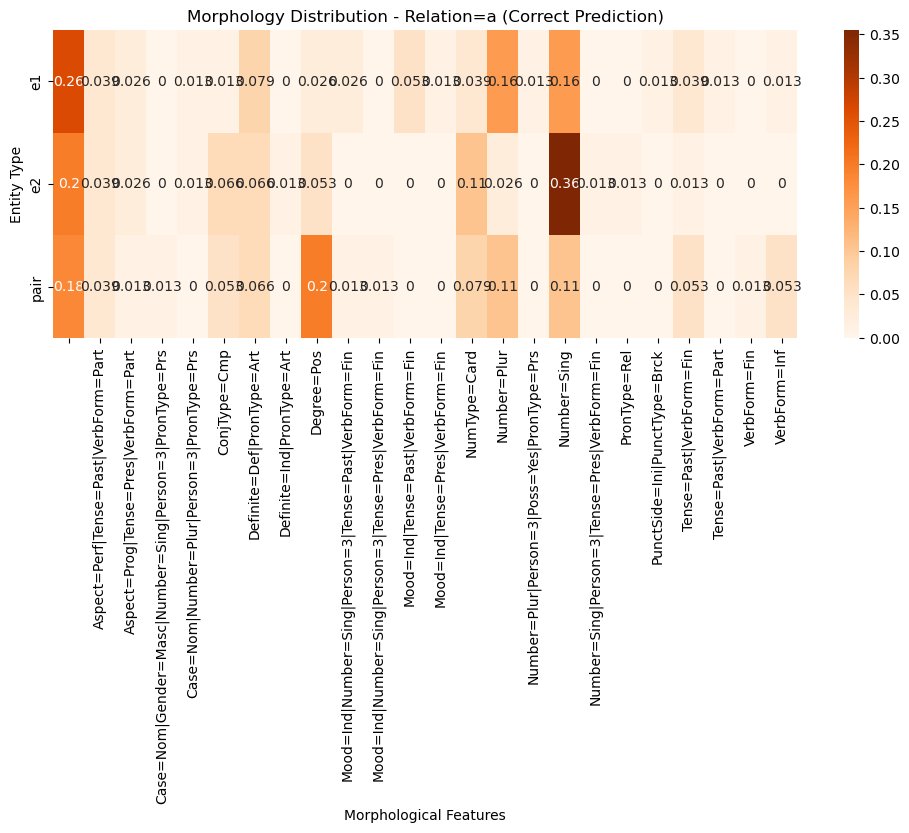

In [57]:
analyze_pos_dep_morph_by_relation(df_analysis)